In [190]:
import pandas as pd
from pathlib import Path
from neural_priors.utils.data import Subject, get_all_subject_ids
from neural_priors.encoding_model2.decode import get_decoding_paradigm
import numpy as np
from tqdm.notebook import tqdm
from tqdm.contrib.itertools import product
import pingouin as pg
import seaborn as sns
import matplotlib.pyplot as plt

bids_folder = Path('/data/ds-neuralpriors')



subject = '02'


def get_pdf(subject, smoothed=False, model_label=4, fit_responses=False, n_voxels=100, spherical_noise=False):
    # Load subject
    sub = Subject(subject, bids_folder=bids_folder)

    # Create target folder
    key = f'model{model_label}'

    if smoothed:
        key += '.smoothed'

    if spherical_noise:
        key += '.spherical_noise'

    if fit_responses:
        key += '.fit_responses'

    target_dir = bids_folder / 'derivatives' / 'decoding2' / key / f'sub-{subject}' / 'func'

    # sub-04_mask-NPCr_nvoxels-100_pars.tsv
    pdf = pd.read_csv(target_dir / f'sub-{subject}_mask-NPCr_nvoxels-{n_voxels}_pars.tsv', sep='\t', index_col=[0,1], header=[0,1], )
    paradigm = get_decoding_paradigm(sub, fit_responses=fit_responses, drop_levels=False)
    pdf.index = paradigm.index

    pdf.set_index(paradigm['x'], append=True, inplace=True)
    pdf.set_index(paradigm['range'], append=True, inplace=True)

    pdf.columns.names = ['n', 'range']

    # Make first level of columns float 32
    new_columns = pd.MultiIndex.from_arrays([pdf.columns.get_level_values(0).astype(np.float32), pdf.columns.get_level_values(1)], names=pdf.columns.names)

    # Assign the new MultiIndex back to the DataFrame
    pdf.columns = new_columns

    return pdf

def summarize_pdf(pdf):
    pdf0 = pdf.xs('0.0', level=1, axis=1)
    
    pdf0 /= np.trapz(pdf0, pdf0.columns.astype(np.float32), axis=1)[:, np.newaxis]
    E0 = np.trapz(pdf0 * pdf0.columns.values.astype(float)[np.newaxis, :], pdf0.columns.astype(np.float32), axis=1)

    sd0 = np.trapz(np.abs(E0[:, np.newaxis] - pdf0.columns.values.astype(float)[np.newaxis, :]) * pdf0, pdf0.columns.astype(np.float32), axis=1)

    pdf1 = pdf.xs('1.0', level=1, axis=1)
    pdf1 /= np.trapz(pdf1, pdf1.columns.astype(np.float32), axis=1)[:, np.newaxis]
    E1 = np.trapz(pdf1 * pdf1.columns.values.astype(float)[np.newaxis, :], pdf1.columns.astype(np.float32), axis=1)
    sd1 = np.trapz(np.abs(E1[:, np.newaxis] - pdf1.columns.values.astype(float)[np.newaxis, :]) * pdf1, pdf1.columns.astype(np.float32), axis=1)

    ix_ = pd.IndexSlice

    pdf0_ = pdf0.loc[:, :25]
    pdf0_ /= np.trapz(pdf0_, pdf0_.columns.astype(np.float32), axis=1)[:, np.newaxis]

    E20 = np.trapz(pdf0_ * pdf0_.columns.values.astype(float)[np.newaxis, :], pdf0_.columns.astype(np.float32), axis=1)
    E21 = E1

    E = np.where(pdf.index.get_level_values('range') == 0.0, E0, E1)
    E2 = np.where(pdf.index.get_level_values('range') == 0.0, E20, E21)
    sd = np.where(pdf.index.get_level_values('range') == 0.0, sd0, sd1)

    E_swapped = np.where(pdf.index.get_level_values('range') == 0.0, E1, E0)

    pars = pd.DataFrame(index=pdf.index, columns=['E', 'sd'])
    pars['E'] = E
    pars['E2'] = E2
    pars['sd'] = sd
    pars['E_swapped'] = E_swapped

    pars.reset_index(['x', 'range'], inplace=True)

    pars['error'] = pars['E'] - pars['x']
    pars['abs(error)'] = np.abs(pars['error'])

    pars['error2'] = pars['E2'] - pars['x']
    pars['abs(error2)'] = np.abs(pars['error2'])


    return pars

In [163]:
subjects = get_all_subject_ids()

smootheds = [True]

model_labels = [15, 18]
n_voxels_ = [0, 100][:1]

spherical_noise = [True]

pdfs = []
keys = []
pars = []

for subject, smoothed, model_label, fit_responses, n_voxels, spherical_noise in product(subjects, smootheds, model_labels, [False], n_voxels_, [True]):
    try:
        pdf = get_pdf(subject, smoothed=smoothed, model_label=model_label, fit_responses=fit_responses, n_voxels=n_voxels, spherical_noise=spherical_noise)
        pars_ = summarize_pdf(pdf)
        pdfs.append(pdf)
        keys.append((subject, smoothed, model_label, fit_responses, n_voxels, spherical_noise))
        pars.append(pars_.droplevel('subject'))
    except FileNotFoundError as e:
        print(f'File not found for subject {subject}, smoothed={smoothed}, model_label={model_label}, fit_responses={fit_responses}, n_voxels={n_voxels}: {e}')
        continue
    except Exception as e:
        print(f'Error for subject {subject}, smoothed={smoothed}, model_label={model_label}, fit: {e}, {fit_responses}, (n_voxels={n_voxels})')
        continue

pdf = pd.concat(pdfs, keys=keys, names=['subject', 'smoothed', 'model_label', 'fit_responses', 'n_voxels', 'spherical_noise'])
pars = pd.concat(pars, keys=keys, names=['subject', 'smoothed', 'model_label', 'fit_responses', 'n_voxels', 'spherical_noise'])

  0%|          | 0/78 [00:00<?, ?it/s]

In [164]:
pars['magnitude'] = (pars['x'] < 26).map({True:'low', False: 'high'})
pars['range'] = pars['range'].map({0.0:'Narrow', 1.0:'Wide'})

# Correlation between E and x

/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_96758/1607682992.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  r = pars.groupby(['subject', 'spherical_noise', 'range', 'model_label']).apply(lambda x: pg.corr(x['E'], x['x']))
/Users/gdehol/mambaforge/envs/neural_priors/lib/python3.9/site-packages/seaborn/axisgrid.py:854: UserWarning: The palette list has more values (10) than needed (3), which may not be intended.
  func(*plot_args, **plot_kwargs)
/Users/gdehol/mambaforge/envs/neural_priors/lib/python3.9/site-packages/seaborn/axisgrid.py:854: UserWarning: 
The palette list has fewer values (1) than needed (3) and will cycle, which may produce an uninterpretable plot.
  func(*plot_

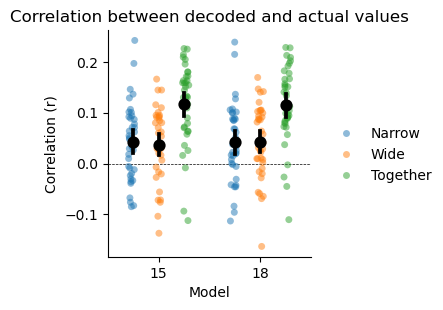

In [213]:
r = pars.groupby(['subject', 'spherical_noise', 'range', 'model_label']).apply(lambda x: pg.corr(x['E'], x['x']))

r2 = pars.groupby(['subject', 'spherical_noise', 'model_label']).apply(lambda x: pg.corr(x['E'], x['x']))
r2['range'] = 'Together'
r2 = r2.reset_index().set_index(['subject', 'spherical_noise', 'range', 'model_label'])
r = pd.concat([r.droplevel(-1), r2])



g = sns.FacetGrid(r.reset_index(), )

g.map_dataframe(sns.stripplot, y='r', x='model_label', hue='range', jitter=True, alpha=0.5, palette=sns.color_palette(), dodge=True)
g.add_legend()

g.map_dataframe(sns.pointplot, y='r', x='model_label', hue='range', linestyle='none', palette=['k'], dodge=.5, zorder=10)

g.map(plt.axhline, y=0, color='k', linestyle='--', linewidth=0.5)

g.set(title='Correlation between decoded and actual values', xlabel='Model', ylabel='Correlation (r)')

r.to_csv(bids_folder / 'derivatives' / 'results_june2025' / 'correlation_decoding.tsv', sep='\t')

# Decoding condition conditional on real x

In [174]:
condition_p = pdf.apply(lambda row: row.loc[row.name[-2]], axis=1)

decoded_condition = condition_p.idxmax(axis=1).map({'0.0': 'Narrow', '1.0': 'Wide'})
decoded_condition.name = 'decoded_condition'
pars['decoded_condition'] = decoded_condition.values

/Users/gdehol/mambaforge/envs/neural_priors/lib/python3.9/site-packages/seaborn/axisgrid.py:854: UserWarning: The palette list has more values (10) than needed (2), which may not be intended.
  func(*plot_args, **plot_kwargs)
/Users/gdehol/mambaforge/envs/neural_priors/lib/python3.9/site-packages/seaborn/axisgrid.py:854: UserWarning: 
The palette list has fewer values (1) than needed (2) and will cycle, which may produce an uninterpretable plot.
  func(*plot_args, **plot_kwargs)


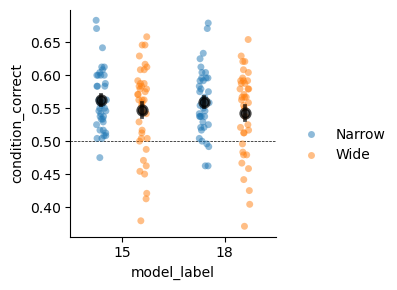

In [175]:
pars['condition_correct'] = pars['decoded_condition'] == pars['range']


g = sns.FacetGrid(pars.groupby(['subject', 'range', 'model_label'])['condition_correct'].mean().reset_index())
g.map_dataframe(sns.stripplot, 'model_label', 'condition_correct', hue='range', dodge=.25, alpha=0.5, jitter=True, palette=sns.color_palette())
g.add_legend()
g.map_dataframe(sns.pointplot, x='model_label', y='condition_correct', hue='range', dodge=.4, linestyle='none', palette=['k'], zorder=100, alpha=.7, errorbar='se')

g.map(plt.axhline, y=0.5, color='k', linestyle='--', linewidth=0.5)

/Users/gdehol/mambaforge/envs/neural_priors/lib/python3.9/site-packages/seaborn/axisgrid.py:854: UserWarning: The palette list has more values (10) than needed (3), which may not be intended.
  func(*plot_args, **plot_kwargs)
/Users/gdehol/mambaforge/envs/neural_priors/lib/python3.9/site-packages/seaborn/axisgrid.py:854: UserWarning: 
The palette list has fewer values (1) than needed (3) and will cycle, which may produce an uninterpretable plot.
  func(*plot_args, **plot_kwargs)


<Figure size 600x600 with 0 Axes>

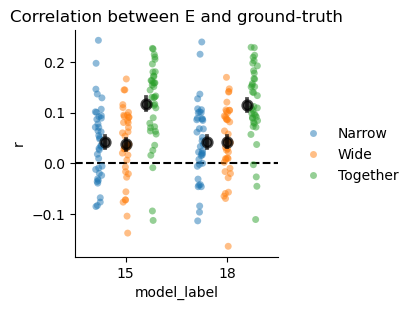

In [231]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Sample data creation for demonstration
# Replace this with your actual data
# Create a strip plot
plt.figure(figsize=(6, 6))


g = sns.FacetGrid(r.reset_index())
g.map_dataframe(sns.stripplot, 'model_label', 'r', hue='range', dodge=.25, alpha=0.5, jitter=True, palette=sns.color_palette())
g.add_legend()
g.map_dataframe(sns.pointplot, x='model_label', y='r', hue='range', dodge=.4, linestyle='none', palette=['k'], zorder=100, alpha=.7, errorbar='se')

plt.axhline(0.0, c='k', ls='--')

g.set(title="Correlation between E and ground-truth")

/Users/gdehol/mambaforge/envs/neural_priors/lib/python3.9/site-packages/seaborn/axisgrid.py:854: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(*plot_args, **plot_kwargs)
/Users/gdehol/mambaforge/envs/neural_priors/lib/python3.9/site-packages/seaborn/axisgrid.py:854: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(*plot_args, **plot_kwargs)
/Users/gdehol/mambaforge/envs/neural_priors/lib/python3.9/site-packages/seaborn/axisgrid.py:854: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(*plot_args, **plot_kwargs)
/Users/gdehol/mambaforge/envs/neural_priors/lib/python3.9/site-packages/seaborn/axisgrid.py:854: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(*plot_args, **plot_kwargs)


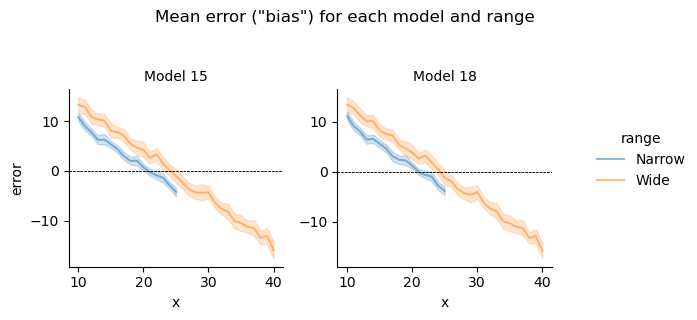

In [236]:
error = pars.groupby(['subject', 'model_label', 'range', 'x'])['error'].mean()


g = sns.FacetGrid(error.reset_index(), hue='range', col='model_label', margin_titles=True, sharey=False, sharex=False)

g.map(sns.lineplot, 'x', 'error', palette=sns.color_palette(), alpha=0.5)
g.add_legend()

mean_narrow = (10+25) / 2
mean_wide = (25+40) / 2

g.set_titles(col_template='Model {col_name}')
g.fig.suptitle('Mean error ("bias") for each model and range', y=1.05)

g.map(plt.axhline, y=0, color='k', linestyle='--', linewidth=0.5)

error.to_csv(bids_folder / 'derivatives' / 'results_june2025' / 'mean_error.tsv', sep='\t')

/Users/gdehol/mambaforge/envs/neural_priors/lib/python3.9/site-packages/seaborn/axisgrid.py:854: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(*plot_args, **plot_kwargs)
/Users/gdehol/mambaforge/envs/neural_priors/lib/python3.9/site-packages/seaborn/axisgrid.py:854: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(*plot_args, **plot_kwargs)
/Users/gdehol/mambaforge/envs/neural_priors/lib/python3.9/site-packages/seaborn/axisgrid.py:854: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(*plot_args, **plot_kwargs)
/Users/gdehol/mambaforge/envs/neural_priors/lib/python3.9/site-packages/seaborn/axisgrid.py:854: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(*plot_args, **plot_kwargs)


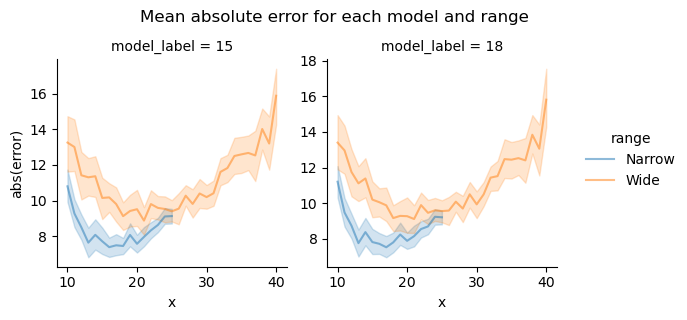

In [235]:
mse = pars.groupby(['subject', 'model_label', 'range', 'x'])['abs(error)'].mean()


g = sns.FacetGrid(mse.reset_index(), hue='range', col='model_label', margin_titles=True, sharey=False, sharex=False)

g.map(sns.lineplot, 'x', 'abs(error)', palette=sns.color_palette(), alpha=0.5)
g.add_legend()

g.fig.suptitle('Mean absolute error for each model and range', y=1.05)


mse.to_csv(bids_folder / 'derivatives' / 'results_june2025' / 'mean_absolute_error_decoding.tsv', sep='\t')

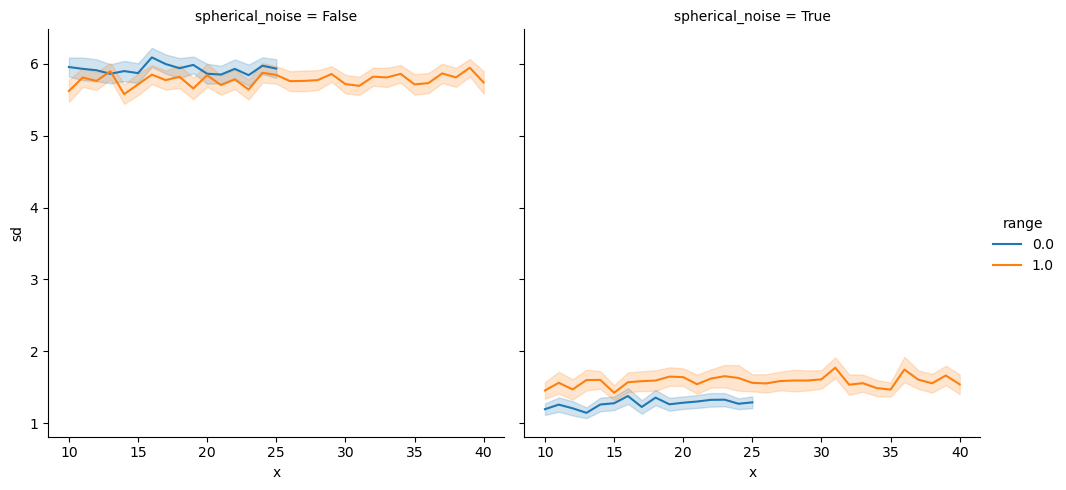

In [81]:
tmp = pars.groupby(['subject', 'x', 'range', 'spherical_noise'])['sd'].mean()

sns.relplot(data=tmp.reset_index(), x='x', y='sd', hue='range', col='spherical_noise', kind='line', errorbar='se')

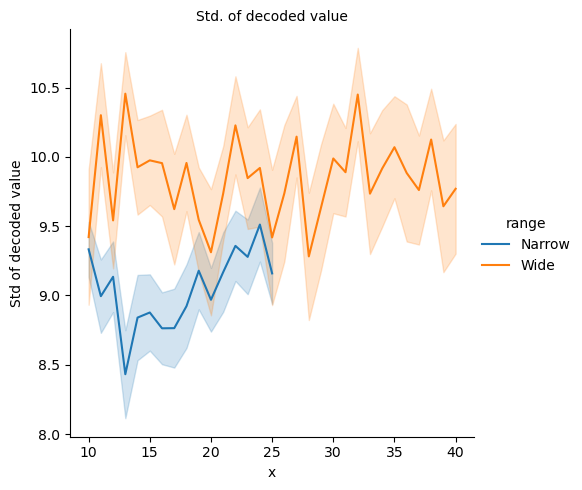

In [233]:
# VARIANCE OF ESTIMSTE AS FUNCTION OF X (actual data)

tmp = pars.groupby(['subject', 'x', 'range', 'spherical_noise'])['E'].std()
tmp = tmp.groupby(['subject', 'x', 'range', 'spherical_noise']).mean()
tmp.name = 'Std of decoded value'


g = sns.relplot(data=tmp.reset_index(), x='x', y='Std of decoded value', hue='range', col='spherical_noise', kind='line', errorbar='se')

g.set_titles(col_template='Std. of decoded value')

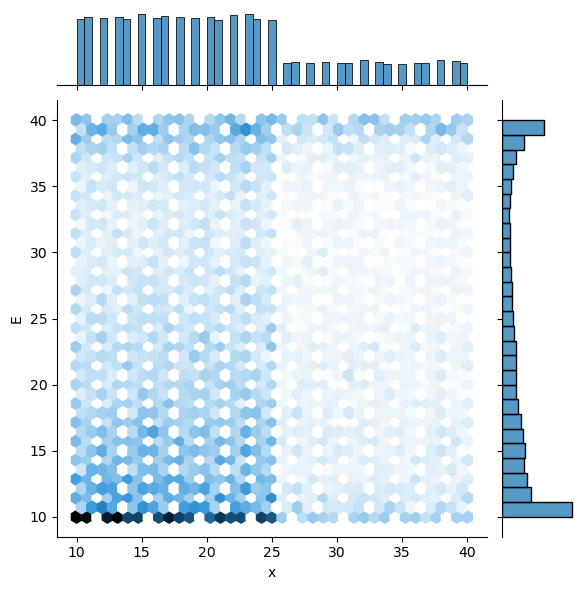

In [246]:
# sns.histplot(pars, x='x', y='E', hue='range')


sns.jointplot(data=pars.reset_index(), x='x', y='E', palette=sns.color_palette(), 
              kind='hex')

<Axes: xlabel='E', ylabel='Count'>

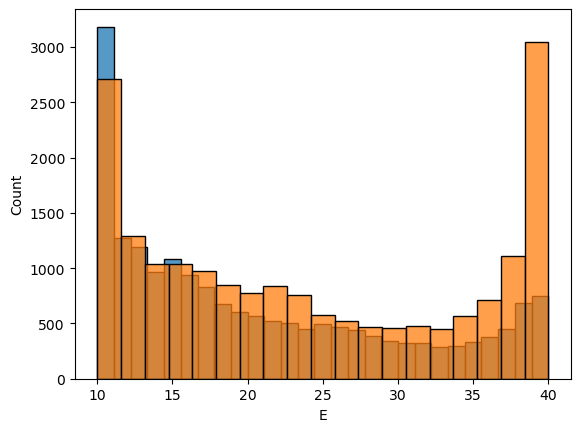

In [254]:
sns.histplot(pars[pars.range == 'Narrow']['E'])
sns.histplot(pars[pars.range == 'Wide']['E'])

# Decoded uncertainy

/Users/gdehol/mambaforge/envs/neural_priors/lib/python3.9/site-packages/seaborn/axisgrid.py:854: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(*plot_args, **plot_kwargs)
/Users/gdehol/mambaforge/envs/neural_priors/lib/python3.9/site-packages/seaborn/axisgrid.py:854: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(*plot_args, **plot_kwargs)
/Users/gdehol/mambaforge/envs/neural_priors/lib/python3.9/site-packages/seaborn/axisgrid.py:854: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(*plot_args, **plot_kwargs)
/Users/gdehol/mambaforge/envs/neural_priors/lib/python3.9/site-packages/seaborn/axisgrid.py:854: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(*plot_args, **plot_kwargs)


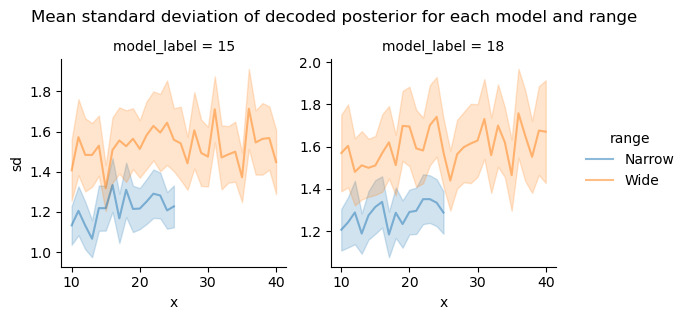

In [262]:
sd = pars.groupby(['subject', 'x', 'range', 'model_label'])['sd'].mean()


g = sns.FacetGrid(sd.reset_index(), hue='range', col='model_label', margin_titles=True, sharey=False, sharex=False)
g.map(sns.lineplot, 'x', 'sd', palette=sns.color_palette(), alpha=0.5, errorbar='se')
g.add_legend()
g.fig.suptitle('Mean standard deviation of decoded posterior for each model and range', y=1.05)

sd.to_csv(bids_folder / 'derivatives' / 'results_june2025' / 'sd_posterior_decoding.tsv', sep='\t')

<Axes: xlabel='x', ylabel='abs(error)'>

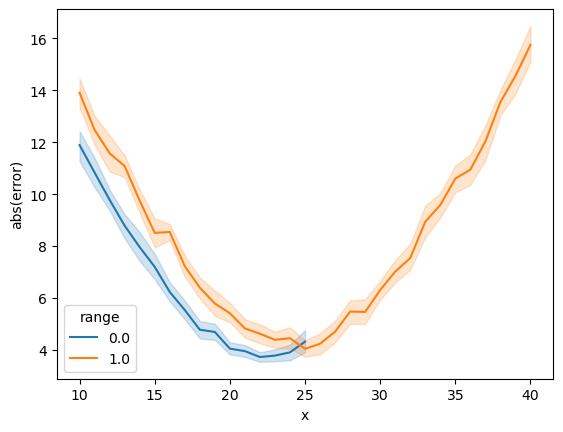

In [50]:
tmp = pars.groupby(['subject', 'x', 'range'])['abs(error)'].mean()

sns.lineplot(data=tmp.reset_index(), x='x', y='abs(error)', hue='range')

<Axes: xlabel='x', ylabel='abs(error2)'>

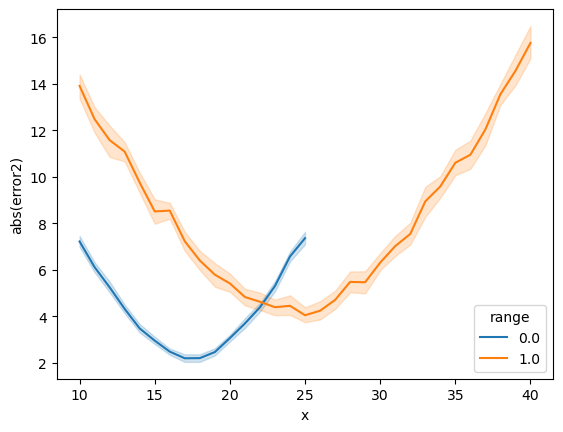

In [51]:
tmp = pars.groupby(['subject', 'x', 'range'])['abs(error2)'].mean()

sns.lineplot(data=tmp.reset_index(), x='x', y='abs(error2)', hue='range')

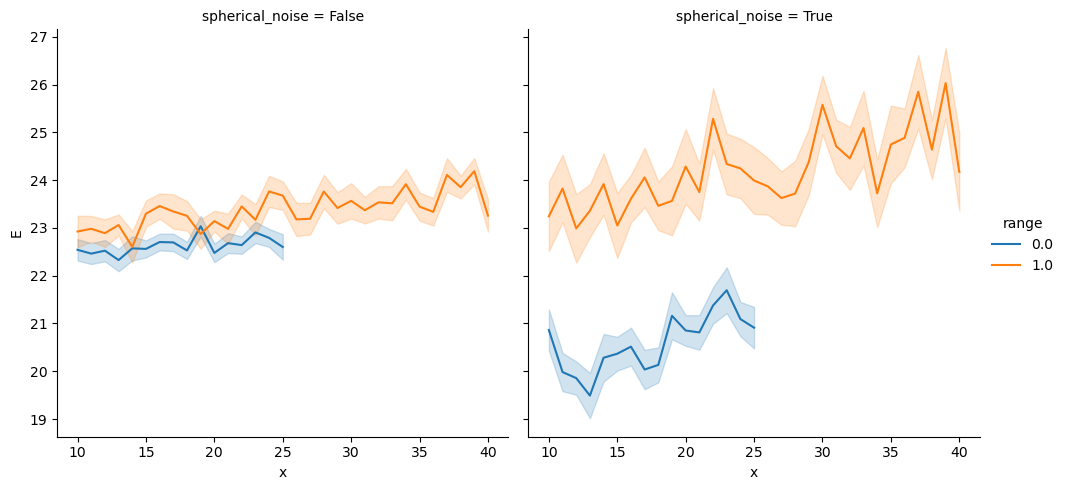

In [89]:
tmp = pars.groupby(['subject', 'x', 'range', 'spherical_noise'])['E'].mean()

sns.relplot(data=tmp.reset_index(), x='x', y='E', hue='range', col='spherical_noise', kind='line', errorbar='se')


<Axes: xlabel='x', ylabel='E2'>

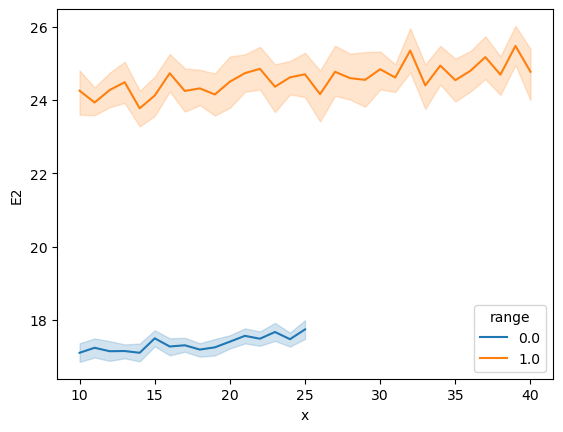

In [39]:
tmp = pars.groupby(['subject', 'x', 'range'])['E2'].mean()

sns.lineplot(data=tmp.reset_index(), x='x', y='E2', hue='range')


/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_16210/1105135720.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  r = pars.groupby(['subject', 'model_label', 'fit_responses', 'smoothed', 'magnitude', 'n_voxels', 'spherical_noise', 'range']).apply(lambda d: pg.corr(d['E'], d['x']))


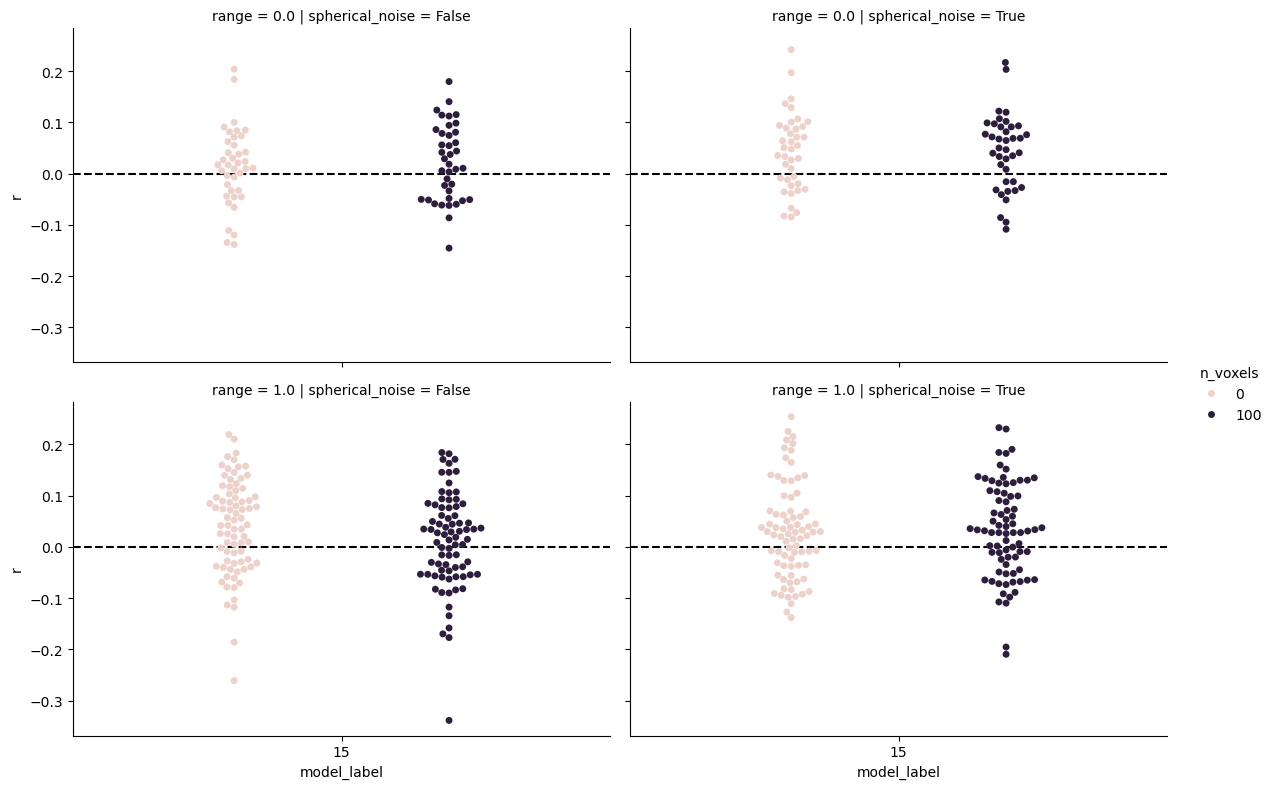

In [90]:
r = pars.groupby(['subject', 'model_label', 'fit_responses', 'smoothed', 'magnitude', 'n_voxels', 'spherical_noise', 'range']).apply(lambda d: pg.corr(d['E'], d['x']))

g = sns.catplot(data=r.reset_index(), y='r', x='model_label', kind='swarm', height=4, aspect=1.5, errorbar='se', col='spherical_noise', row='range', hue='n_voxels', dodge=True)

g.map(plt.axhline, y=0.0, c='k', ls='--')

/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_16210/1979252795.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  r = pars.groupby(['subject', 'model_label', 'fit_responses', 'smoothed', 'magnitude', 'n_voxels', 'range']).apply(lambda d: pg.corr(d['E'], d['x']))


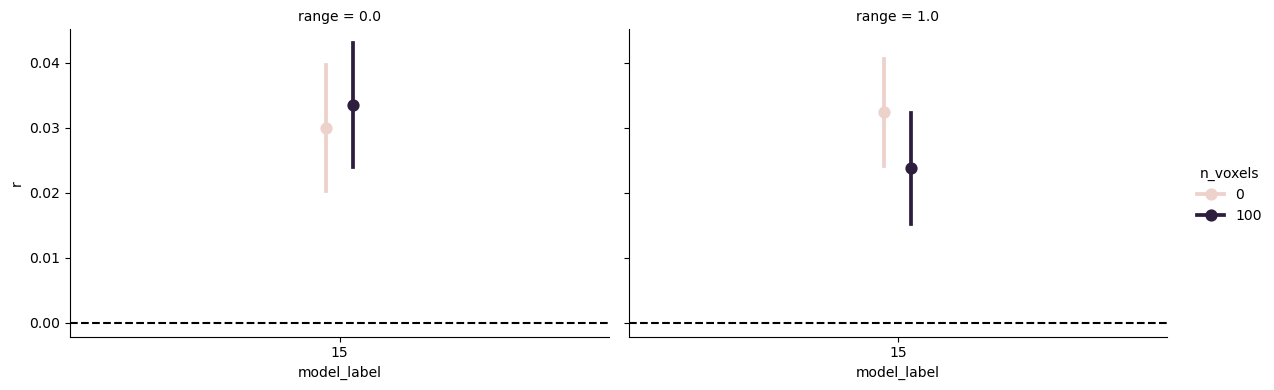

In [69]:
r = pars.groupby(['subject', 'model_label', 'fit_responses', 'smoothed', 'magnitude', 'n_voxels', 'range']).apply(lambda d: pg.corr(d['E'], d['x']))

g = sns.catplot(data=r.reset_index(), y='r', x='model_label', kind='point', height=4, aspect=1.5, errorbar='se', col='range', hue='n_voxels', dodge=True,)

g.map(plt.axhline, y=0.0, c='k', ls='--')

/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_16210/2750514501.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  r = pars.groupby(['subject', 'model_label', 'fit_responses', 'smoothed', 'magnitude']).apply(lambda d: pg.corr(d['E'], d['x']))


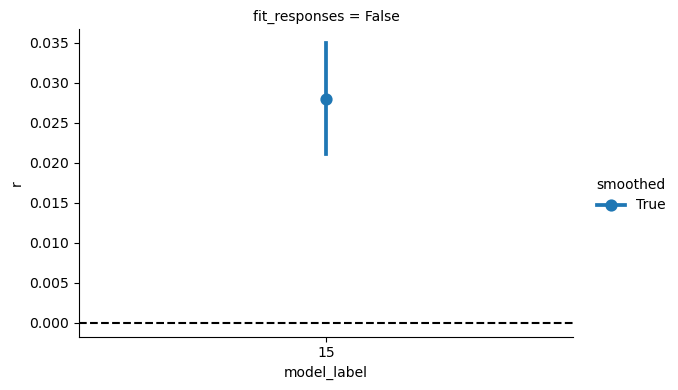

In [70]:
r = pars.groupby(['subject', 'model_label', 'fit_responses', 'smoothed', 'magnitude']).apply(lambda d: pg.corr(d['E'], d['x']))

g = sns.catplot(data=r.reset_index(), y='r', x='model_label', kind='point', height=4, aspect=1.5, errorbar='se', col='fit_responses', hue='smoothed')

g.map(plt.axhline, y=0.0, c='k', ls='--')

In [75]:
pars

x  \
subject smoothed model_label fit_responses n_voxels spherical_noise session run2 trial_nr run         
01      True     15          False         0        True            1       1    1        1    11.0   
                                                                                 2        1    23.0   
                                                                                 3        1    23.0   
                                                                                 4        1    22.0   
                                                                                 5        1    21.0   
...                                                                                             ...   
41      True     15          False         100      False           2       4    26       8    24.0   
                                                                                 27       8    19.0   
                                                                                 28       8    17.0   
                                                                                 29       8    19.0   
                                                                                 30       8    19.0   

                                                                                               range  \
subject smoothed model_label fit_responses n_voxels spherical_noise session run2 trial_nr run          
01      True     15          False         0        True            1       1    1        1      0.0   
                                                                                 2        1      0.0   
                                                                                 3        1      0.0   
                                                                                 4        1      0.0   
                                                                                 5        1      0.0   
...                                                                                              ...   
41      True     15          False         100      False           2       4    26       8      0.0   
                                                                                 27       8      0.0   
                                                                                 28       8      0.0   
                                                                                 29       8      0.0   
                                                                                 30       8      0.0   

                                                                                                       E  \
subject smoothed model_label fit_responses n_voxels spherical_noise session run2 trial_nr run              
01      True     15          False         0        True            1       1    1        1    32.616245   
                                                                                 2        1    30.384667   
                                                                                 3        1    39.365867   
                                                                                 4        1    11.258319   
                                                                                 5        1    28.890953   
...                                                                                                  ...   
41      True     15          False         100      False           2       4    26       8    32.018865   
                                                                                 27       8    28.850672   
                                                                                 28       8    20.552950   
                                                                                 29       8    18.088340   
                                                                                 30       8    27.866747   



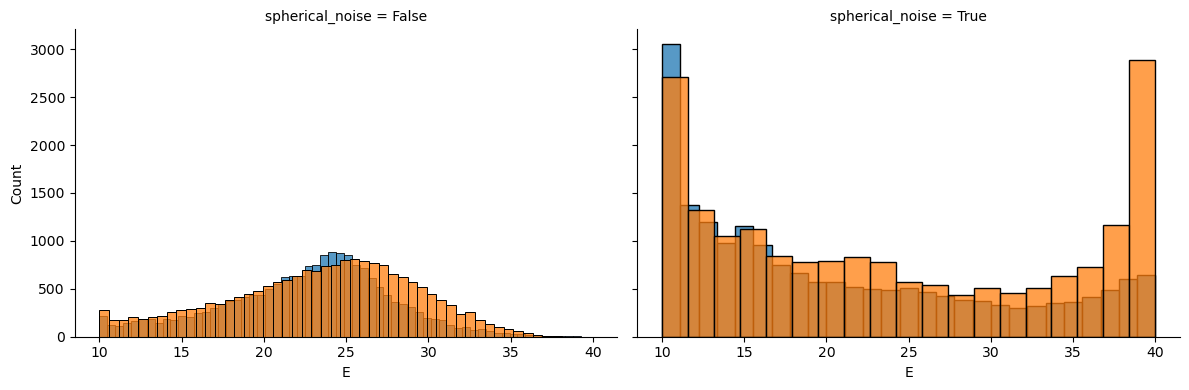

In [76]:
g = sns.FacetGrid(pars.reset_index(), hue='range', col='spherical_noise', height=4, aspect=1.5)

g.map(sns.histplot, 'E')

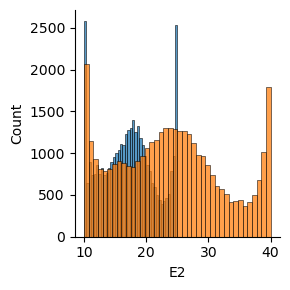

In [72]:
g = sns.FacetGrid(pars, hue='range')

g.map(sns.histplot, 'E2')

/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_41958/2655788227.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  r = pars.groupby(['subject', 'model_label', 'smoothed', 'range', 'n_voxels', 'fit_responses']).apply(lambda d: pg.corr(d['E'], d['x']))


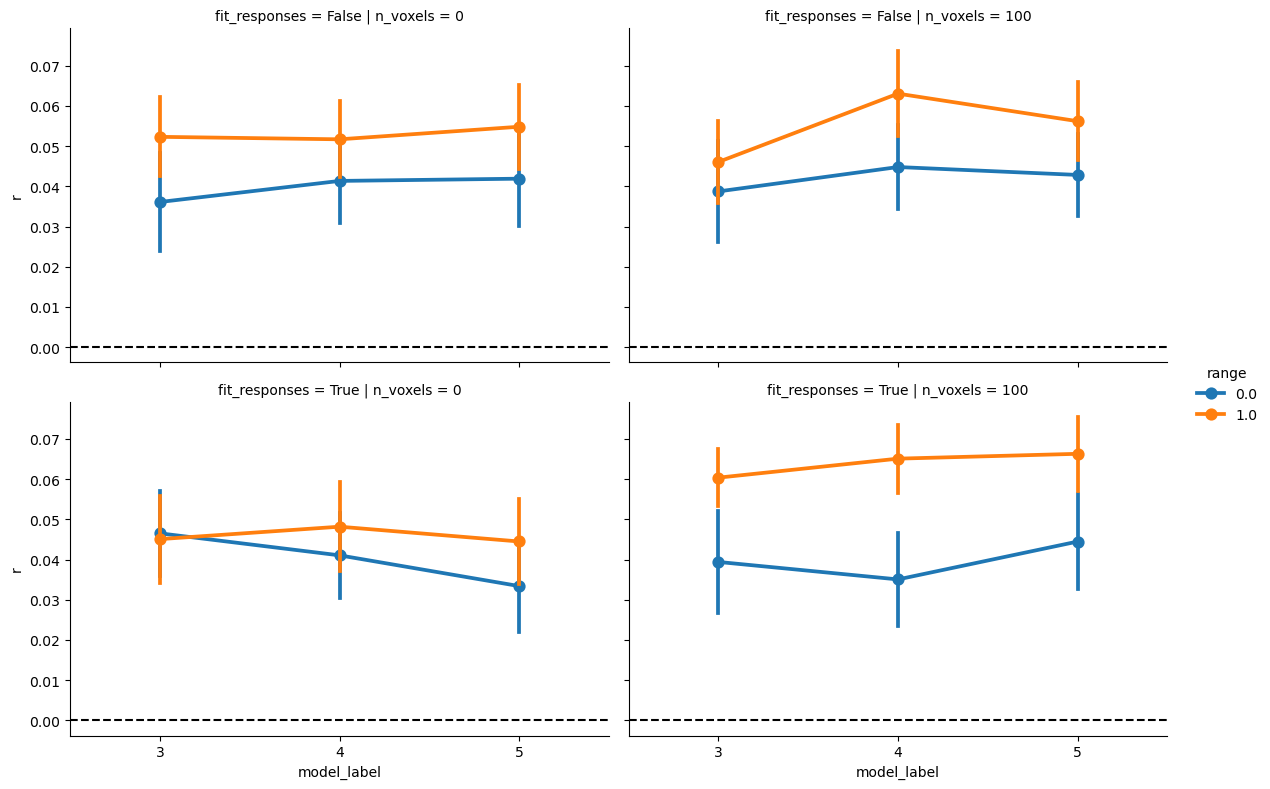

In [41]:
r = pars.groupby(['subject', 'model_label', 'smoothed', 'range', 'n_voxels', 'fit_responses']).apply(lambda d: pg.corr(d['E'], d['x']))

g = sns.catplot(data=r.reset_index(), y='r', x='model_label', kind='point', height=4, aspect=1.5, errorbar='se', hue='range', col='n_voxels', row='fit_responses')

g.map(plt.axhline, y=0.0, c='k', ls='--')

/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_41958/2141776531.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  r = pars.groupby(['subject', 'model_label', 'fit_responses', 'smoothed', 'range']).apply(lambda d: pg.corr(d['E2'], d['x']))


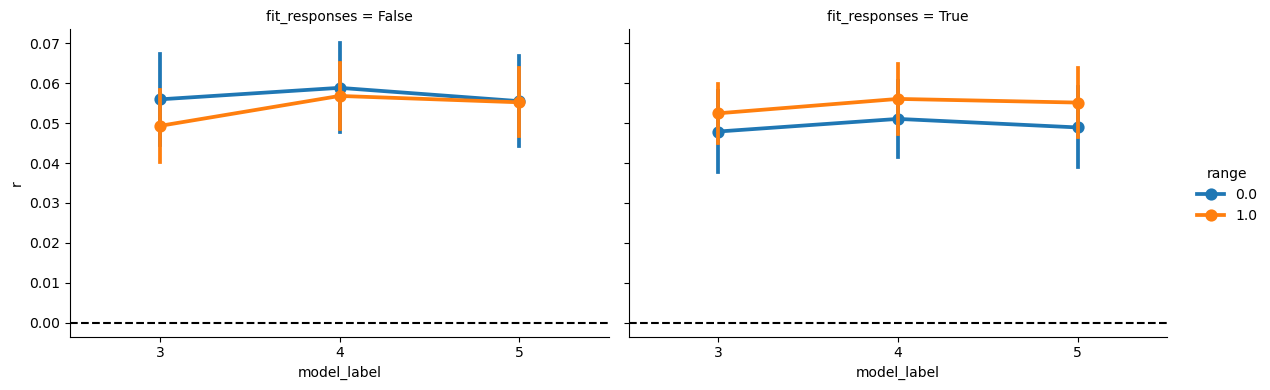

In [39]:
r = pars.groupby(['subject', 'model_label', 'fit_responses', 'smoothed', 'range']).apply(lambda d: pg.corr(d['E2'], d['x']))

g = sns.catplot(data=r.reset_index(), y='r', x='model_label', kind='point', height=4, aspect=1.5, errorbar='se', col='fit_responses', hue='range')

g.map(plt.axhline, y=0.0, c='k', ls='--')

In [10]:
pars = pars.xs(False, level='smoothed')

/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_41958/1465537129.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  r = pars.groupby(['subject', 'model_label', 'range', 'fit_responses', 'magnitude']).apply(lambda d: pg.corr(d['E'], d['x']))


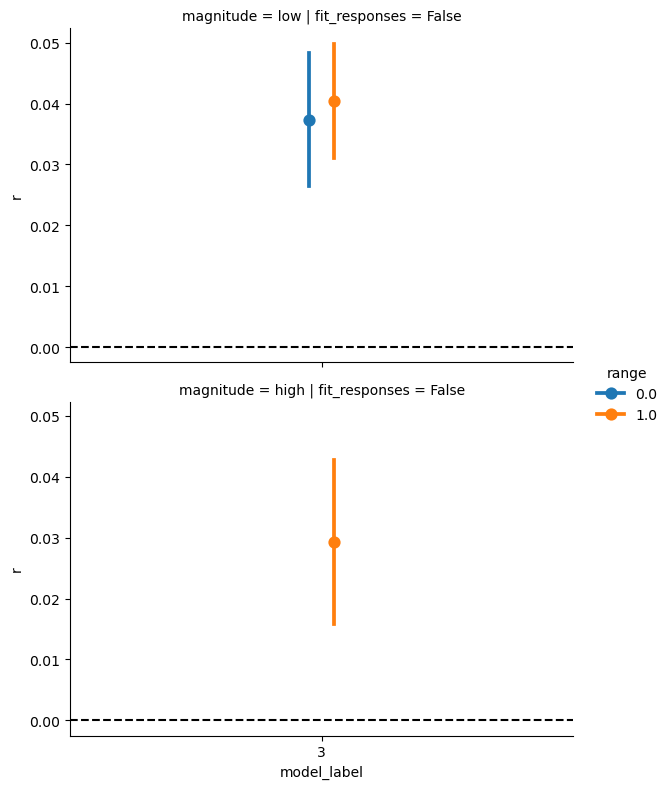

In [11]:
r = pars.groupby(['subject', 'model_label', 'range', 'fit_responses', 'magnitude']).apply(lambda d: pg.corr(d['E'], d['x']))

g = sns.catplot(data=r.reset_index(), y='r', hue='range', x='model_label', kind='point', height=4, aspect=1.5, errorbar='se', col='fit_responses', row='magnitude', dodge=True)

g.map(plt.axhline, y=0.0, c='k', ls='--')

/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_41958/224394720.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  r = pars.groupby(['subject', 'model_label', 'range', 'fit_responses', 'magnitude']).apply(lambda d: pg.corr(d['E'], d['x']))


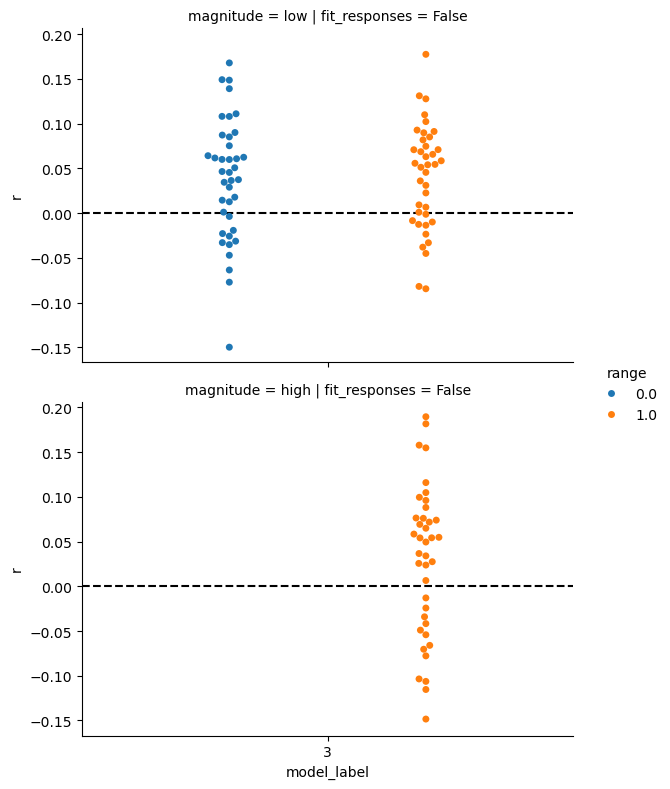

In [12]:
r = pars.groupby(['subject', 'model_label', 'range', 'fit_responses', 'magnitude']).apply(lambda d: pg.corr(d['E'], d['x']))

g = sns.catplot(data=r.reset_index(), y='r', hue='range', x='model_label', kind='swarm', height=4, aspect=1.5, errorbar='se', col='fit_responses', row='magnitude', dodge=True)

g.map(plt.axhline, y=0.0, c='k', ls='--')

In [34]:
tmp = pars.xs(False, 0, level='fit_responses')

tmp['x_bin'] = pd.cut(tmp['x'], bins=np.arange(10, 41, 3.), include_lowest=True).apply(lambda x: x.mid)
tmp = tmp.groupby(['subject', 'range', 'x_bin', 'model_label'])[['sd']].mean()


sns.relplot(x='x_bin', y='sd', hue='range', data=tmp, kind='line', errorbar='se', aspect=1., col='model_label', row='n_voxels')

/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_41958/3814097612.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tmp['x_bin'] = pd.cut(tmp['x'], bins=np.arange(10, 41, 3.), include_lowest=True).apply(lambda x: x.mid)
/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_41958/3814097612.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tmp = tmp.groupby(['subject', 'range', 'x_bin', 'model_label'])[['sd']].mean()


ValueError: Could not interpret value `n_voxels` for `row`. An entry with this name does not appear in `data`.

In [14]:
tmp = pars.xs(5, 0, level='model_label').xs(False, 0, level='fit_responses')

tmp['x_bin'] = pd.cut(tmp['x'], bins=np.arange(10, 41, 5), include_lowest=True).apply(lambda x: x.mid)
tmp = tmp.groupby(['subject', 'range', 'x_bin'])[['abs(error']].mean()


sns.relplot(x='x_bin', y='abs(error', hue='range', data=tmp, kind='line', errorbar='se', aspect=2.)

KeyError: 5

/Users/gdehol/mambaforge/envs/neural_priors/lib/python3.9/site-packages/seaborn/axisgrid.py:854: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(*plot_args, **plot_kwargs)
/Users/gdehol/mambaforge/envs/neural_priors/lib/python3.9/site-packages/seaborn/axisgrid.py:854: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(*plot_args, **plot_kwargs)
/Users/gdehol/mambaforge/envs/neural_priors/lib/python3.9/site-packages/seaborn/axisgrid.py:854: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(*plot_args, **plot_kwargs)
/Users/gdehol/mambaforge/envs/neural_priors/lib/python3.9/site-packages/seaborn/axisgrid.py:854: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(*plot_args, **plot_kwargs)
/Users/gdehol/mambaforge/envs/neural_priors/lib/python3.9/site-packages/seaborn/axisgrid.py:854: UserWarning: Ignoring `palette` because no `hue` variable has been assi

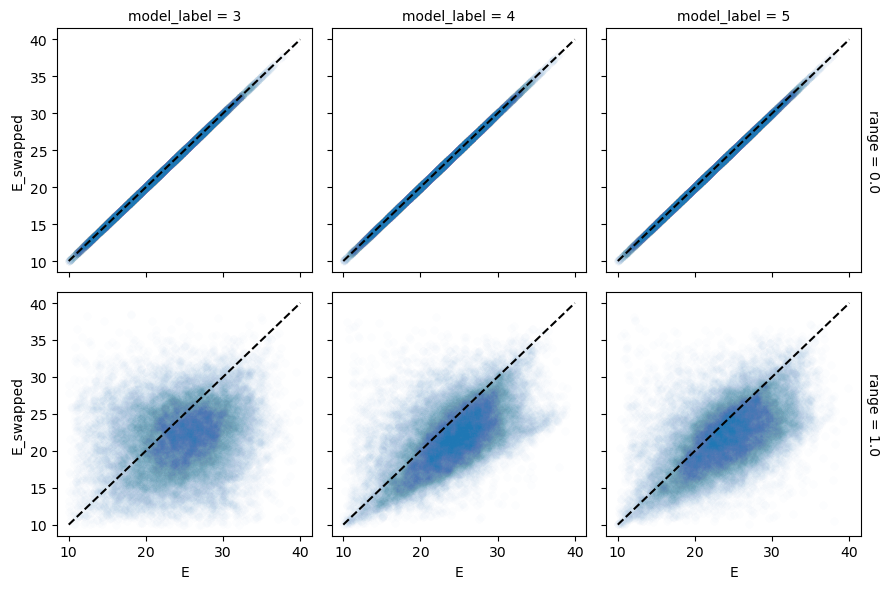

In [ ]:
g = sns.FacetGrid(pars.reset_index(), col='model_label', row='range', margin_titles=True, despine=False, height=3, aspect=1.)

g.map_dataframe(sns.scatterplot, x='E', y='E_swapped', alpha=0.01, palette='tab10', legend=False)

g.map(lambda *args, **kwargs: plt.plot([10, 40], [10, 40], c='k', ls='--'))


# sns.scatterplot(data=pars.reset_index(), x='E', y='E_swapped', hue='range', alpha=0.01, )

# plt.plot([10, 40], [10, 40], c='k', ls='--')

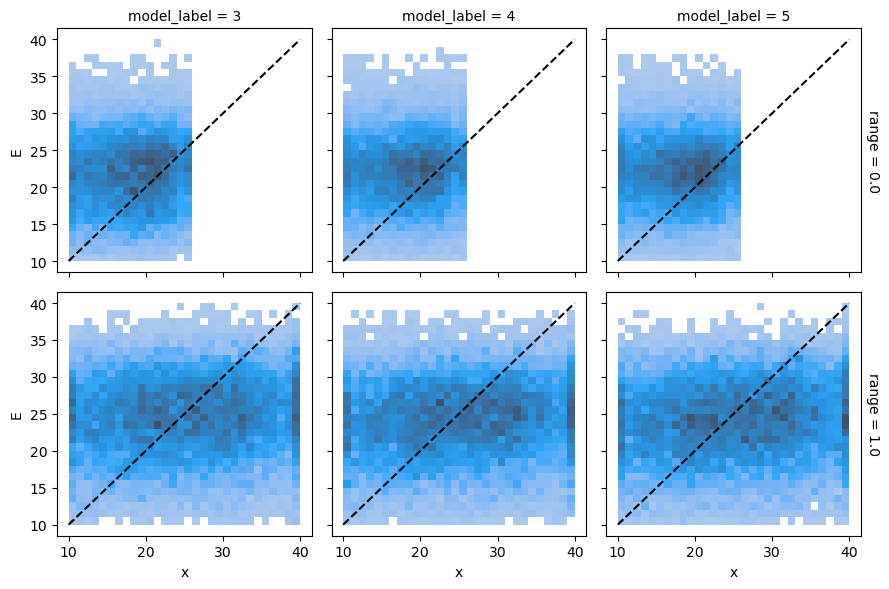

In [ ]:
g = sns.FacetGrid(pars.reset_index(), col='model_label', row='range', margin_titles=True, despine=False, height=3, aspect=1.)

g.map_dataframe(sns.histplot, x='x', y='E', legend=False, bins=[np.arange(10, 41), np.arange(10, 41)], )

g.map(lambda *args, **kwargs: plt.plot([10, 40], [10, 40], c='k', ls='--'))


# sns.scatterplot(data=pars.reset_index(), x='E', y='E_swapped', hue='range', alpha=0.01, )

# plt.plot([10, 40], [10, 40], c='k', ls='--')

ValueError: operands could not be broadcast together with shapes (480,) (224160,) (224160,) 

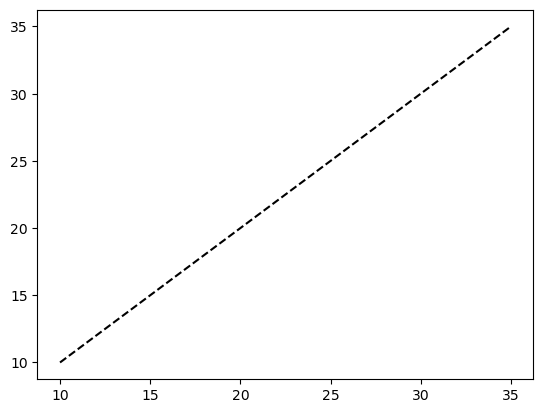

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pdf0 = pdf.xs('0.0', level=1, axis=1)
pdf0 /= np.trapz(pdf0, pdf0.columns.astype(np.float32), axis=1)[:, np.newaxis]
E0 = np.trapz(pdf0 * pdf0.columns.values.astype(float)[np.newaxis, :], pdf0.columns.astype(np.float32), axis=1)

sd0 = np.trapz(np.abs(E0[:, np.newaxis] - pdf0.columns.values.astype(float)[np.newaxis, :]) * pdf0, pdf0.columns.astype(np.float32), axis=1)

pdf1 = pdf.xs('1.0', level=1, axis=1)
pdf1 /= np.trapz(pdf1, pdf1.columns.astype(np.float32), axis=1)[:, np.newaxis]
E1 = np.trapz(pdf1 * pdf1.columns.values.astype(float)[np.newaxis, :], pdf1.columns.astype(np.float32), axis=1)
sd1 = np.trapz(np.abs(E1[:, np.newaxis] - pdf1.columns.values.astype(float)[np.newaxis, :]) * pdf1, pdf1.columns.astype(np.float32), axis=1)


plt.scatter(E0, E1, alpha=0.5)

plt.plot([10, 35], [10, 35], 'k--')

E = np.where(paradigm['range'] == 0.0, E0, E1)
sd = np.where(paradigm['range'] == 0.0, sd0, sd1)

plt.figure(figsize=(10, 5))
data = paradigm.copy()
data['E'] = E
data['sd'] = sd
data['error'] = np.abs(E - data['x'])

data['x_bin'] = pd.cut(data['x'], bins=10).apply(lambda x: x.mid)
# sns.lmplot(x=paradigm['x'], y=E, hue=paradigm['range'])
sns.lmplot(x='x', y='E', hue='range', data=data, palette=['C0', 'C1'], height=5, aspect=2)

plt.figure()
sns.relplot(x='x_bin', y='sd', hue='range', data=data, palette=['C0', 'C1'], height=5, aspect=2, kind='line')

plt.figure()
sns.rplot(x='error', y='sd', hue='range', data=data, palette=['C0', 'C1'], )

In [ ]:
import pingouin as pg
pg.corr(data['x'], data['E'], method='pearson', )

,n,r,CI95%,p-val,BF10,power
pearson,480,0.262837,"[0.18, 0.34]",5.018492e-09,1.435e+06,0.999956


In [ ]:
data.groupby('range').apply(lambda x: pg.corr(x['x'], x['E'], method='pearson'))

/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_76377/1912188916.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  data.groupby('range').apply(lambda x: pg.corr(x['x'], x['E'], method='pearson'))


,,n,r,CI95%,p-val,BF10,power
range,,,,,,,
0.0,pearson,240,0.041651,"[-0.09, 0.17]",0.520768,0.099,0.098431
1.0,pearson,240,0.105010,"[-0.02, 0.23]",0.104631,0.299,0.369146


In [ ]:
data.groupby('range').apply(lambda x: pg.corr(x['error'], x['sd'], method='pearson'))

/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_76377/692938194.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  data.groupby('range').apply(lambda x: pg.corr(x['error'], x['sd'], method='pearson'))


,,n,r,CI95%,p-val,BF10,power
range,,,,,,,
0.0,pearson,240,0.169522,"[0.04, 0.29]",0.008499,2.524,0.751791
1.0,pearson,240,-0.024587,"[-0.15, 0.1]",0.704707,0.087,0.066566


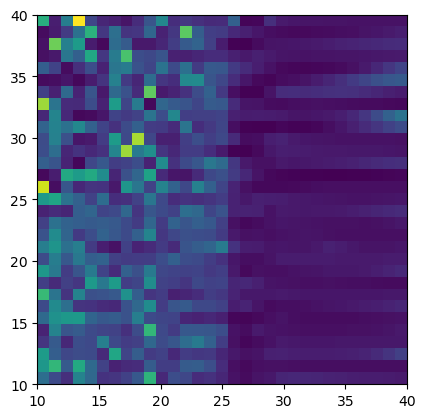

In [ ]:
plt.imshow(pdf0.set_index(paradigm['x']).groupby('x').mean(), extent=[10, 40, 10,40], origin='lower')

In [ ]:
data.groupby('range')[['x', 'E', 'sd', 'error']].mean()

,x,E,sd,error
range,,,,
0.0,17.475000,19.651914,4.205623,5.149401
1.0,24.958334,24.202438,4.828053,8.224808


In [17]:
sub = Subject('02')

sub.get_prf_parameters_volume2(model_label=5)

mu          sd       alpha      delta_wide      lower_bound_range  \
      narrow wide narrow wide narrow wide     narrow wide            narrow   
0        0.0  0.0    0.0  0.0    0.0  0.0        0.0  0.0               0.0   
1        0.0  0.0    0.0  0.0    0.0  0.0        0.0  0.0               0.0   
2        0.0  0.0    0.0  0.0    0.0  0.0        0.0  0.0               0.0   
3        0.0  0.0    0.0  0.0    0.0  0.0        0.0  0.0               0.0   
4        0.0  0.0    0.0  0.0    0.0  0.0        0.0  0.0               0.0   
...      ...  ...    ...  ...    ...  ...        ...  ...               ...   
85948    0.0  0.0    0.0  0.0    0.0  0.0        0.0  0.0               0.0   
85949    0.0  0.0    0.0  0.0    0.0  0.0        0.0  0.0               0.0   
85950    0.0  0.0    0.0  0.0    0.0  0.0        0.0  0.0               0.0   
85951    0.0  0.0    0.0  0.0    0.0  0.0        0.0  0.0               0.0   
85952    0.0  0.0    0.0  0.0    0.0  0.0        0.0  0.0               0.0   

           amplitude      baseline        r2 cvr2  
      wide    narrow wide   narrow wide  NaN  NaN  
0      0.0       0.0  0.0      0.0  0.0  0.0  0.0  
1      0.0       0.0  0.0      0.0  0.0  0.0  0.0  
2      0.0       0.0  0.0      0.0  0.0  0.0  0.0  
3      0.0       0.0  0.0      0.0  0.0  0.0  0.0  
4      0.0       0.0  0.0      0.0  0.0  0.0  0.0  
...    ...       ...  ...      ...  ...  ...  ...  
85948  0.0       0.0  0.0      0.0  0.0  0.0  0.0  
85949  0.0       0.0  0.0      0.0  0.0  0.0  0.0  
85950  0.0       0.0  0.0      0.0  0.0  0.0  0.0  
85951  0.0       0.0  0.0      0.0  0.0  0.0  0.0  
85952  0.0       0.0  0.0      0.0  0.0  0.0  0.0  

[85953 rows x 16 columns]